In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 

warnings.filterwarnings('ignore')

Load Dataset

In [3]:
df = pd.read_csv('Salary Data.csv')
df.head(10)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
5,29.0,Male,Bachelor's,Marketing Analyst,2.0,55000.0
6,42.0,Female,Master's,Product Manager,12.0,120000.0
7,31.0,Male,Bachelor's,Sales Manager,4.0,80000.0
8,26.0,Female,Bachelor's,Marketing Coordinator,1.0,45000.0
9,38.0,Male,PhD,Senior Scientist,10.0,110000.0


Data Cleaning

In [4]:
df.info()
df.describe()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    str    
 2   Education Level      373 non-null    str    
 3   Job Title            373 non-null    str    
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 17.7 KB


(375, 6)

In [5]:

df.duplicated().sum()

np.int64(50)

In [6]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [7]:
df.drop_duplicates(inplace= True)
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.fillna(df.mode().iloc[0])
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

EDA               || Target = Salary

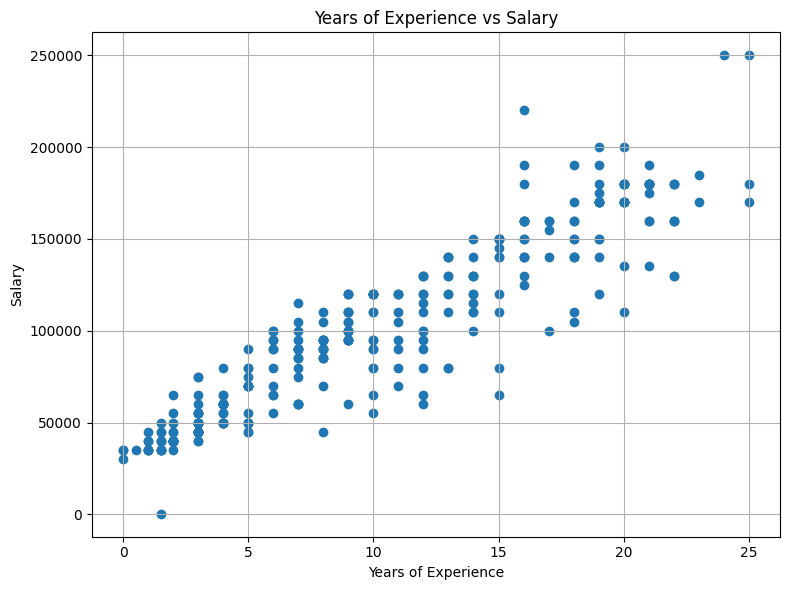

In [9]:
plt.figure(figsize = (8,6))
plt.scatter(df["Years of Experience"], df['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Years of Experience vs Salary')
plt.tight_layout()
plt.grid(True)
plt.show()

Check the correlation

In [10]:
df[['Years of Experience', 'Salary']].corr()

,Years of Experience,Salary
Years of Experience,1.000000,0.924717
Salary,0.924717,1.000000


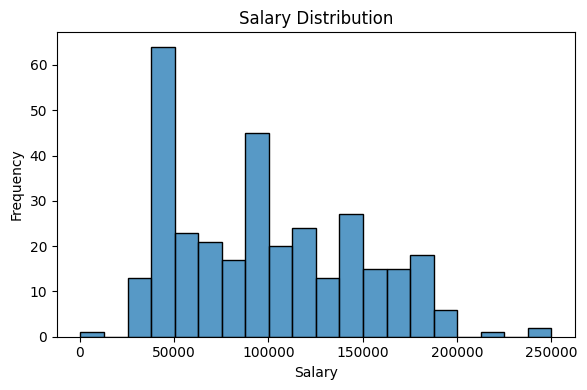

In [11]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['Salary'], bins= 20)
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.title('Salary Distribution')
plt.tight_layout()
plt.show()

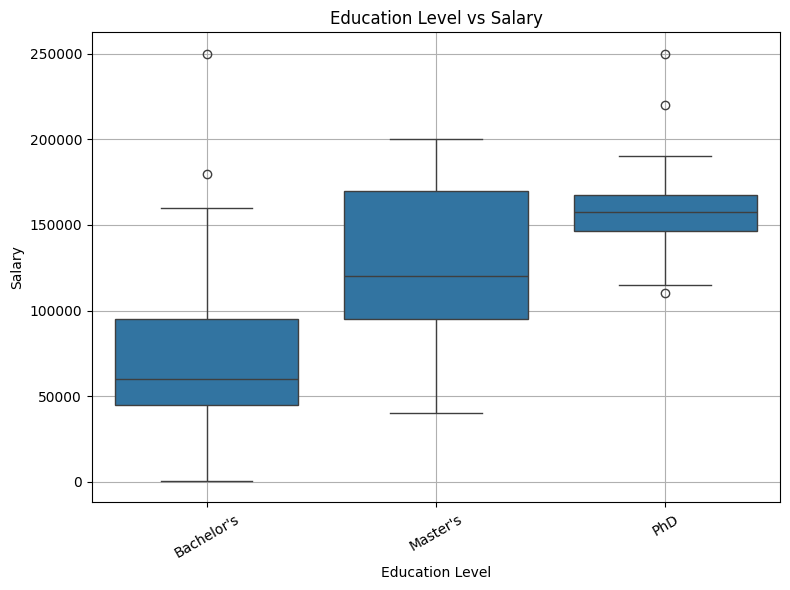

In [12]:
plt.figure(figsize= (8,6))
sns.boxplot(x = 'Education Level',
            y= 'Salary',
            data = df
)

plt.xlabel('Education Level')
plt.ylabel('Salary')
plt.title('Education Level vs Salary')

plt.xticks(rotation=30)
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='str')

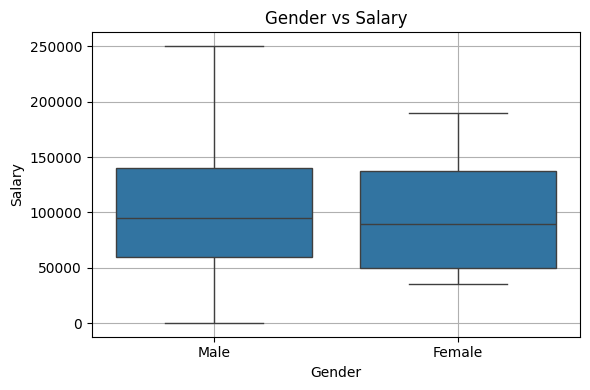

In [14]:
plt.figure(figsize = (6,4))
sns.boxplot(x ='Gender',
            y = 'Salary' ,
            data = df)


plt.xlabel('Gender')
plt.ylabel('Salary')
plt.title("Gender vs Salary")
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
imp_jobs = df['Job Title'].value_counts().head(10).index

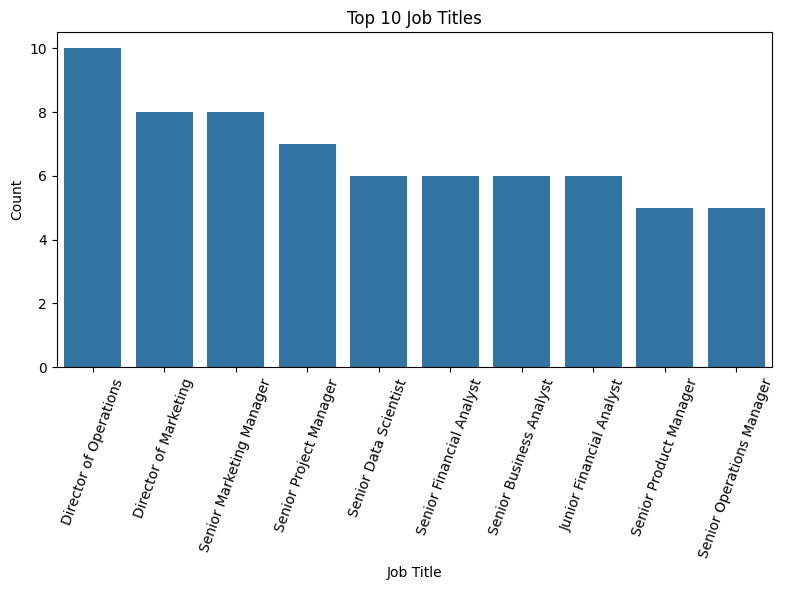

In [16]:
plt.figure(figsize=(8,6))
sns.barplot(x =imp_jobs,
            y = df['Job Title'].value_counts().head(10).values)


plt.xlabel('Job Title')
plt.ylabel('Count')
plt.title('Top 10 Job Titles')

plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 325 entries, 0 to 371
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  325 non-null    float64
 1   Gender               325 non-null    str    
 2   Education Level      325 non-null    str    
 3   Job Title            325 non-null    str    
 4   Years of Experience  325 non-null    float64
 5   Salary               325 non-null    float64
dtypes: float64(3), str(3)
memory usage: 17.8 KB


In [18]:
df['Gender'].value_counts()

Gender
Male      171
Female    154
Name: count, dtype: int64

Encoding

In [19]:
df['Gender'] = df['Gender'].map({
    'Male' : 0,
    'Female' : 1
})
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,0,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,1,Master's,Data Analyst,3.0,65000.0
2,45.0,0,PhD,Senior Manager,15.0,150000.0
3,36.0,1,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,0,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
348,28.0,1,Bachelor's,Junior Operations Manager,1.0,35000.0
349,36.0,0,Bachelor's,Senior Business Development Manager,8.0,110000.0
350,44.0,1,PhD,Senior Data Scientist,16.0,160000.0
351,31.0,0,Bachelor's,Junior Marketing Coordinator,3.0,55000.0


Male = 0

Femle = 1